# Plot single-cell doubling times

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# from macrohet import plot

# Setup
sns.set(style="white", font="Nimbus Sans")
sns.set_palette(['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91'])
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

### Load single-cell data

#### Using CSV

In [2]:
pickle_path = '/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl'
df = pd.read_pickle(pickle_path)
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


# Style dev

In [6]:
df = df[df['mtb_origin']=='Growth'].copy()


In [5]:

# Define the expanded_piyg color map
expanded_piyg = [
    '#1a9641',  # First color from sns.color_palette('PiYG')
    '#a6d96a',  # Second color from sns.color_palette('PiYG')
    '#978897',  # Rose Quartz in hexadecimal format
    '#d1d1ca',  # Timberwolf in RGB normalized form
    '#f1b6da',  # Second-to-last color from sns.color_palette('PiYG')
    '#d02c91'   # Last color from sns.color_palette('PiYG')
]

In [8]:
color_map = {
    # CTRL: Two hues (WT vs RD1) from a single color base (green)
    'CTRL': {
        'WT': '#1A9641',  # Dark Green
        'RD1': '#A6D96A'   # Light Green
    },
    # PZA: Unique color (pink/magenta), hues for concentration
    'PZA': {
        # 'EC0': expanded_piyg[4],  # Light Pink
        'EC50': '#4D488F', # Using light pink (change this if you have a mid-tone)
        'EC99': '#6EAFD7'  # Dark Magenta
    },
    # INH: Unique color (grey), hues for concentration
    'INH': {
        # 'EC0': expanded_piyg[3],  # Light Grey
        'EC50': '#CC99FF',  # Medium Grey
        'EC99': '#AA58F5'  # Using medium grey (change this)
    },
    # RIF: Unique color (re-using green), hues for concentration
    'RIF': {
        # 'EC0': expanded_piyg[1],  # Light Green (re-used)
        'EC50': '#F1C2F2',  # Dark Green (re-used)
        'EC99': '#D02C91'  # Using dark green (change this)
    }
}

# Colors for the RIGHT PANEL (Stacked Bar)
fast_c, normal_c, slow_c = expanded_piyg[0], expanded_piyg[3], expanded_piyg[5]


/tmp/ipykernel_194649/4024040449.py:90: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_194649/4024040449.py:120: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_194649/4024040449.py:120: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_194649/4024040449.py:120: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_194649/4024040449.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


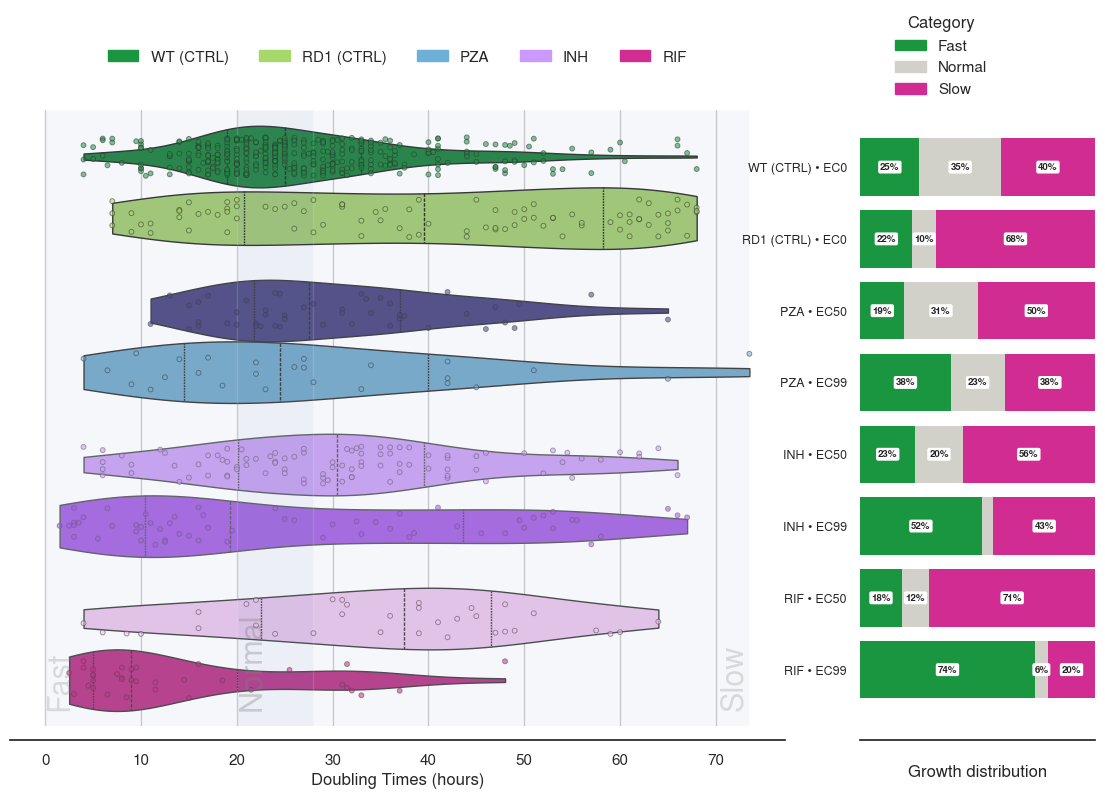

In [9]:
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# Theme
sns.set_theme(style="white")
try:
    plt.rcParams["font.family"] = "Nimbus Sans"
except Exception:
    plt.rcParams["font.family"] = "Nimbus Sans"

width_in = 14
height_in = 8
bar_height = 0.8
# Your preferred color palette
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']
# ---------------------------------------------------------


# Normalize fields
for c in ("Compound", "Strain"):
    if c in df:
        df[c] = df[c].astype(str)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)

# Force CTRL → EC0
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

# Scalarize and clean doubling times
if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
    df = df.explode("Doubling Times", ignore_index=True)

df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
# actually remove ±inf (assign back)
df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

# De-dupe repeated points
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# Derived labels
bins = [0, 20, 28, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                    df["Strain_norm"] + " (CTRL)",
                                    df["Compound"])

strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
concentration_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# ---------- Colors ----------


# MODIFICATION: New color dictionary for LEFT PANEL (Violin/Strip)
# This provides the nested dictionary structure you requested.
# You can edit any hex code value here to change the plot colors.
# --------------------------


# Figure
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# ---------- LEFT PANEL: VIOLIN + STRIP ----------
# CTRL only: hue = CTRL Type (WT vs RD1)
ctrl_df = df[df["Mtb Strain or Drug Compound"] == "CTRL"]
if not ctrl_df.empty:
    # MODIFICATION: Use color_map to build palette
    ctrl_pal = [color_map['CTRL']['WT'], color_map['CTRL']['RD1']]
    
    # violins
    sns.violinplot(
        data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="CTRL Type", order=strain_order, dodge=True,
        palette=ctrl_pal, inner='quart', cut=0, scale="width",
        linewidth=1.0, ax=ax
    )
    if ax.legend_:
        ax.legend_.remove()
    # scatter overlay
    sns.stripplot(
        data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="CTRL Type", order=strain_order, dodge=True,
        palette=ctrl_pal, jitter=0.25,
        size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
    )
    if ax.legend_:
        ax.legend_.remove()

# Drugs: per compound, hue = Concentration
drug_df = df[df["Mtb Strain or Drug Compound"] != "CTRL"]
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if sub.empty:
        continue
    present = [c for c in concentration_order if c in sub["Concentration"].unique()]
    
    # MODIFICATION: Build palette from color_map based on compound AND concentration
    pal = [color_map[compound][conc] for conc in present]

    # violins
    sns.violinplot(
        data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="Concentration", order=strain_order, hue_order=present,
        dodge=True, palette=pal, inner='quart', cut=0, scale="width",
        linewidth=1.0, ax=ax
    )
    if ax.legend_:
        ax.legend_.remove()

    # scatter overlay
    sns.stripplot(
        data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="Concentration", order=strain_order, hue_order=present,
        dodge=True, palette=pal, jitter=0.25,
        size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
    )
    if ax.legend_:
        ax.legend_.remove()

# Bands + labels
xmax = float(df["Doubling Times"].max())
ax.axvspan(0, 20, alpha=0.05)
ax.axvspan(20, 28, alpha=0.10)
ax.axvspan(28, xmax, alpha=0.05)
ymax = len(strain_order) - 0.65
ax.text(0,  ymax, "Fast",   fontsize=22, color="gray", alpha=0.25, ha="left",  rotation=90)
ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left",  rotation=90)
ax.text(xmax, ymax, "Slow",  fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

ax.set_xlabel("Doubling Times (hours)")
ax.set_ylabel("")
ax.set_yticks([])

ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# MODIFICATION: Legend (explicit)
# Updated to reflect the new compound-based color logic.
# Shows one representative color for each group.
legend_handles = [
    mpatches.Patch(color=color_map['CTRL']['WT'], label="WT (CTRL)"),
    mpatches.Patch(color=color_map['CTRL']['RD1'], label="RD1 (CTRL)"),
    mpatches.Patch(color=color_map['PZA']['EC99'], label="PZA"), # Using EC99 color as representative
    mpatches.Patch(color=color_map['INH']['EC50'], label="INH"), # Using EC50 color as representative
    mpatches.Patch(color=color_map['RIF']['EC99'], label="RIF"), # Using EC99 color as representative
]
ax.legend(handles=legend_handles, loc="upper center",
            bbox_to_anchor=(0.5, 1.12), ncol=5, frameon=False)

# ---------- RIGHT PANEL: STACKED BARS ----------
# This section is unchanged as it uses the 'fast_c', 'normal_c', 'slow_c'
# variables, which were preserved.
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
        .size()
        .unstack("Growth Category", fill_value=0))

rows = [(comp, conc)
        for comp in right_row_order
        for conc in ["EC50", "EC0", "EC99"]
        if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if rows:
    g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
    totals = g.sum(axis=1).replace(0, np.nan)
    props = (g.T / totals).T.fillna(0.0)

    y_pos = np.arange(len(props))
    y_labels = [f"{comp} • {conc}" for comp, conc in props.index]
    growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

    lefts = np.zeros(len(props))
    for gr in ["Fast", "Normal", "Slow"]:
        if gr not in props.columns: continue # Check if category exists
        vals = props[gr].values
        bars = ax_bar.barh(
            y=y_pos, width=vals, left=lefts, height=bar_height,
            label=gr, color=growth_colors[gr], edgecolor="none"
        )
        # label percentages
        for bar, v in zip(bars, vals):
            if v > 0.05:
                x_center = bar.get_x() + bar.get_width() / 2
                y_center = bar.get_y() + bar.get_height() / 2
                ax_bar.text(
                    x_center, y_center,
                    f"{v*100:.0f}%", ha="center", va="center",
                    fontsize=7, fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                )
        lefts += vals

    ax_bar.set_xlim(0, 1)
    ax_bar.set_xticks([])
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(y_labels, fontsize=9)
    ax_bar.set_xlabel("\nGrowth distribution")
    ax_bar.set_ylabel("")
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
    ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
else:
    ax_bar.axis("off")

plt.tight_layout()
plt.savefig('temp.pdf', bbox_inches='tight', dpi=314)
plt.show()

# Previous colours

In [15]:
def doubling_times_with_stacked_bars(subset_df, expanded_piyg,
                                     width_in=12, height_in=6, bar_height=0.6):
    """
    Left: violin + strip plots of doubling times.
    Right: stacked horizontal bars (Fast/Normal/Slow) for groups that exist only.
    CTRL is coerced to EC0 (no blank EC50/EC99 rows). Rows top→bottom:
    WT (CTRL) → RD1 (CTRL) → PZA → INH → RIF.
    """
    import warnings

    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

    # Theme
    sns.set_theme(style="white")
    try:
        plt.rcParams["font.family"] = "Nimbus Sans"
    except Exception:
        plt.rcParams["font.family"] = "Nimbus Sans"

    df = subset_df.copy()

    # Normalize fields
    for c in ("Compound", "Strain"):
        if c in df:
            df[c] = df[c].astype(str)
    df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)

    # Force CTRL → EC0
    df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

    # Scalarize and clean doubling times
    if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
        df = df.explode("Doubling Times", ignore_index=True)

    df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
    # actually remove ±inf (assign back)
    df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
    df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

    # De-dupe repeated points
    keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
    df = df.drop_duplicates(subset=keys).copy()

    # Derived labels
    bins = [0, 20, 28, np.inf]
    labels = ["Fast", "Normal", "Slow"]
    df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

    df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
    rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
    df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
    df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
    df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                      df["Strain_norm"] + " (CTRL)",
                                      df["Compound"])

    strain_order = ["CTRL", "PZA", "INH", "RIF"]
    right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
    concentration_order = ["EC50", "EC0", "EC99"]
    growth_order = ["Fast", "Normal", "Slow"]

    # Colors
    fast_c, normal_c, slow_c = expanded_piyg[0], expanded_piyg[3], expanded_piyg[5]
    ctrl_wt_c, ctrl_rd1_c = expanded_piyg[0], expanded_piyg[1]
    ec50_c, ec0_c, ec99_c = expanded_piyg[4], expanded_piyg[2], expanded_piyg[5]

    # Figure
    fig = plt.figure(figsize=(width_in, height_in))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
    ax = plt.subplot(gs[0])
    ax_bar = plt.subplot(gs[1])

    # ---------- LEFT PANEL: VIOLIN + STRIP ----------
    # CTRL only: hue = CTRL Type (WT vs RD1)
    ctrl_df = df[df["Mtb Strain or Drug Compound"] == "CTRL"]
    if not ctrl_df.empty:
        # violins
        sns.violinplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            palette=[ctrl_wt_c, ctrl_rd1_c], inner='quart', cut=0, scale="width",
            linewidth=1.0, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()
        # scatter overlay
        sns.stripplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            palette=[ctrl_wt_c, ctrl_rd1_c], jitter=0.25,
            size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()

    # Drugs: per compound, hue = Concentration
    drug_df = df[df["Mtb Strain or Drug Compound"] != "CTRL"]
    for compound in ["PZA", "INH", "RIF"]:
        sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
        if sub.empty:
            continue
        present = [c for c in concentration_order if c in sub["Concentration"].unique()]
        pal = [ec50_c if c == "EC50" else ec99_c if c == "EC99" else ec0_c for c in present]

        # violins
        sns.violinplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True, palette=pal, inner='quart', cut=0, scale="width",
            linewidth=1.0, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()

        # scatter overlay
        sns.stripplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True, palette=pal, jitter=0.25,
            size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()

    # Bands + labels
    xmax = float(df["Doubling Times"].max())
    ax.axvspan(0, 20, alpha=0.05)
    ax.axvspan(20, 28, alpha=0.10)
    ax.axvspan(28, xmax, alpha=0.05)
    ymax = len(strain_order) - 0.65
    ax.text(0,  ymax, "Fast",   fontsize=22, color="gray", alpha=0.25, ha="left",  rotation=90)
    ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left",  rotation=90)
    ax.text(xmax, ymax, "Slow",  fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

    ax.set_xlabel("Doubling Times (hours)")
    ax.set_ylabel("")
    ax.set_yticks([])

    ax.xaxis.grid(True)
    sns.despine(offset=10, left=True, ax=ax)

    # Legend (explicit)
    legend_handles = [
        mpatches.Patch(color=ctrl_wt_c, label="Wild-type control"),
        mpatches.Patch(color=ctrl_rd1_c, label="ΔRD1 control"),
        mpatches.Patch(color=ec50_c, label="EC50"),
        mpatches.Patch(color=ec0_c,  label="EC0"),
        mpatches.Patch(color=ec99_c, label="EC99"),
    ]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, 1.12), ncol=5, frameon=False)

    # ---------- RIGHT PANEL: STACKED BARS ----------
    g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
           .size()
           .unstack("Growth Category", fill_value=0))

    rows = [(comp, conc)
            for comp in right_row_order
            for conc in ["EC50", "EC0", "EC99"]
            if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

    if rows:
        g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
        totals = g.sum(axis=1).replace(0, np.nan)
        props = (g.T / totals).T.fillna(0.0)

        y_pos = np.arange(len(props))
        y_labels = [f"{comp} • {conc}" for comp, conc in props.index]
        growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

        lefts = np.zeros(len(props))
        for gr in ["Fast", "Normal", "Slow"]:
            vals = props[gr].values
            bars = ax_bar.barh(
                y=y_pos, width=vals, left=lefts, height=bar_height,
                label=gr, color=growth_colors[gr], edgecolor="none"
            )
            # label percentages
            for bar, v in zip(bars, vals):
                if v > 0.05:
                    x_center = bar.get_x() + bar.get_width() / 2
                    y_center = bar.get_y() + bar.get_height() / 2
                    ax_bar.text(
                        x_center, y_center,
                        f"{v*100:.0f}%", ha="center", va="center",
                        fontsize=7, fontweight="bold",
                        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                    )
            lefts += vals

        ax_bar.set_xlim(0, 1)
        ax_bar.set_xticks([])
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(y_labels, fontsize=9)
        ax_bar.set_xlabel("\nGrowth distribution")
        ax_bar.set_ylabel("")
        ax_bar.invert_yaxis()
        sns.despine(offset=10, left=True, ax=ax_bar)

        handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
        ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
    else:
        ax_bar.axis("off")

    plt.tight_layout()
    plt.savefig('temp.pdf', bbox_inches='tight', dpi=314)
    plt.show()


In [7]:
subset_df = df[df['mtb_origin']=='Growth'].copy()


/tmp/ipykernel_2158413/1665006714.py:109: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/1665006714.py:137: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/1665006714.py:137: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/1665006714.py:137: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/1665006714.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


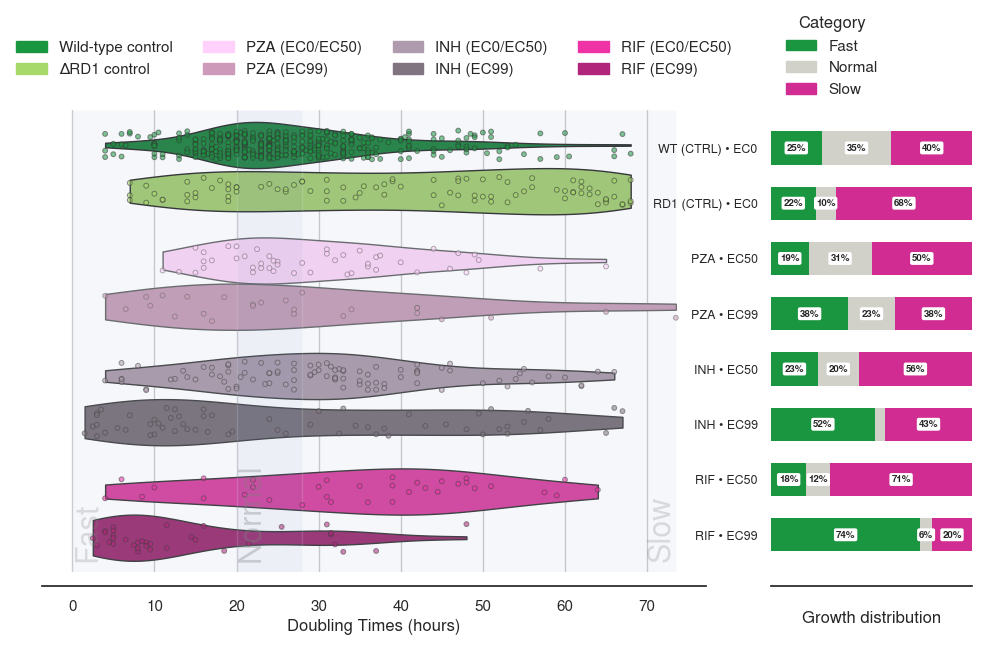

In [20]:
doubling_times_with_stacked_bars(subset_df, expanded_piyg)

In [21]:
def doubling_times_with_stacked_bars(subset_df, expanded_piyg,
                                     width_in=12, height_in=6, bar_height=0.6):
    """
    Left: violin + strip plots of doubling times.
    Right: stacked horizontal bars (Fast/Normal/Slow) for groups that exist only.
    CTRL is coerced to EC0 (no blank EC50/EC99 rows). Rows top→bottom:
    WT (CTRL) → RD1 (CTRL) → PZA → INH → RIF.
    """
    import warnings

    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from matplotlib.colors import to_rgb, to_hex

    warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

    # Theme
    sns.set_theme(style="white")
    plt.rcParams["font.family"] = "Nimbus Sans"

    df = subset_df.copy()

    # Normalize fields
    for c in ("Compound", "Strain"):
        if c in df:
            df[c] = df[c].astype(str)
    df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)

    # Force CTRL → EC0
    df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

    # Scalarize and clean doubling times
    if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
        df = df.explode("Doubling Times", ignore_index=True)

    df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
    df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
    df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

    # De-dupe repeated points
    keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
    df = df.drop_duplicates(subset=keys).copy()

    # Derived labels
    bins = [0, 20, 28, np.inf]
    labels = ["Fast", "Normal", "Slow"]
    df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

    df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
    rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
    df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
    df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
    df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                      df["Strain_norm"] + " (CTRL)",
                                      df["Compound"])

    strain_order = ["CTRL", "PZA", "INH", "RIF"]
    right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
    concentration_order = ["EC50", "EC0", "EC99"]
    growth_order = ["Fast", "Normal", "Slow"]

    # --- Colors ---
    # Right-panel bars:
    fast_c, normal_c, slow_c = expanded_piyg[0], expanded_piyg[3], expanded_piyg[5]

    # Controls (unchanged)
    ctrl_wt_c, ctrl_rd1_c = expanded_piyg[0], expanded_piyg[1]

    # Helper to lighten/darken hex colors
    def _shade(hex_color, factor=1.0):
        r, g, b = to_rgb(hex_color)
        r = min(1, r * factor); g = min(1, g * factor); b = min(1, b * factor)
        return to_hex((r, g, b))

    # Base color per compound → generate (light, dark) pair
    compound_base = {
        "PZA": expanded_piyg[4],  # pink
        "INH": expanded_piyg[2],  # mauve/grey
        "RIF": expanded_piyg[5],  # magenta
    }
    compound_pairs = {k: (_shade(v, 1.15), _shade(v, 0.85)) for k, v in compound_base.items()}

    # Map concentrations to pair: EC0/EC50 → light, EC99 → dark
    def conc_palette_for(compound, present_concs):
        light, dark = compound_pairs[compound]
        def pick(c):
            if c in ("EC0", "EC50"):
                return light
            elif c == "EC99":
                return dark
            return light
        return [pick(c) for c in present_concs]

    # Figure
    fig = plt.figure(figsize=(width_in, height_in))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
    ax = plt.subplot(gs[0])
    ax_bar = plt.subplot(gs[1])

    # ---------- LEFT PANEL: VIOLIN + STRIP ----------
    # CTRL only: hue = CTRL Type (WT vs RD1)
    ctrl_df = df[df["Mtb Strain or Drug Compound"] == "CTRL"]
    if not ctrl_df.empty:
        # violins
        sns.violinplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            palette=[ctrl_wt_c, ctrl_rd1_c], inner=None, cut=0, scale="width",
            linewidth=1.0, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()
        # scatter overlay
        sns.stripplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            palette=[ctrl_wt_c, ctrl_rd1_c], jitter=0.25,
            size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()

    # Drugs: per compound, hue = Concentration with per-compound pair
    drug_df = df[df["Mtb Strain or Drug Compound"] != "CTRL"]
    for compound in ["PZA", "INH", "RIF"]:
        sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
        if sub.empty:
            continue
        present = [c for c in concentration_order if c in sub["Concentration"].unique()]
        pal = conc_palette_for(compound, present)

        # violins
        sns.violinplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True, palette=pal, inner=None, cut=0, scale="width",
            linewidth=1.0, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()

        # scatter overlay
        sns.stripplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True, palette=pal, jitter=0.25,
            size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_:
            ax.legend_.remove()

    # Bands + labels
    xmax = float(df["Doubling Times"].max())
    ax.axvspan(0, 20, alpha=0.05)
    ax.axvspan(20, 28, alpha=0.10)
    ax.axvspan(28, xmax, alpha=0.05)
    ymax = len(strain_order) - 0.65
    ax.text(0,  ymax, "Fast",   fontsize=22, color="gray", alpha=0.25, ha="left",  rotation=90)
    ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left",  rotation=90)
    ax.text(xmax, ymax, "Slow",  fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

    ax.set_xlabel("Doubling Times (hours)")
    ax.set_ylabel("")
    ax.set_yticks([])

    ax.xaxis.grid(True)
    sns.despine(offset=10, left=True, ax=ax)

    # Legend (explicit): controls + per-compound pairs
    legend_handles = [
        # Controls unchanged
        mpatches.Patch(color=ctrl_wt_c, label="Wild-type control"),
        mpatches.Patch(color=ctrl_rd1_c, label="ΔRD1 control"),
        # Compound pairs (light = EC0/EC50, dark = EC99)
        mpatches.Patch(color=compound_pairs["PZA"][0], label="PZA (EC50)"),
        mpatches.Patch(color=compound_pairs["PZA"][1], label="PZA (EC99)"),
        mpatches.Patch(color=compound_pairs["INH"][0], label="INH (EC50)"),
        mpatches.Patch(color=compound_pairs["INH"][1], label="INH (EC99)"),
        mpatches.Patch(color=compound_pairs["RIF"][0], label="RIF (EC50)"),
        mpatches.Patch(color=compound_pairs["RIF"][1], label="RIF (EC99)"),
    ]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, 1.18), ncol=4, frameon=False)

    # ---------- RIGHT PANEL: STACKED BARS ----------
    g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
           .size()
           .unstack("Growth Category", fill_value=0))

    rows = [(comp, conc)
            for comp in right_row_order
            for conc in ["EC50", "EC0", "EC99"]
            if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

    if rows:
        g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
        totals = g.sum(axis=1).replace(0, np.nan)
        props = (g.T / totals).T.fillna(0.0)

        y_pos = np.arange(len(props))
        y_labels = [f"{comp} • {conc}" for comp, conc in props.index]
        growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

        lefts = np.zeros(len(props))
        for gr in ["Fast", "Normal", "Slow"]:
            vals = props[gr].values
            bars = ax_bar.barh(
                y=y_pos, width=vals, left=lefts, height=bar_height,
                label=gr, color=growth_colors[gr], edgecolor="none"
            )
            # label percentages
            for bar, v in zip(bars, vals):
                if v > 0.05:
                    x_center = bar.get_x() + bar.get_width() / 2
                    y_center = bar.get_y() + bar.get_height() / 2
                    ax_bar.text(
                        x_center, y_center,
                        f"{v*100:.0f}%", ha="center", va="center",
                        fontsize=7, fontweight="bold",
                        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                    )
            lefts += vals

        ax_bar.set_xlim(0, 1)
        ax_bar.set_xticks([])
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(y_labels, fontsize=9)
        ax_bar.set_xlabel("\nGrowth distribution")
        ax_bar.set_ylabel("")
        ax_bar.invert_yaxis()
        sns.despine(offset=10, left=True, ax=ax_bar)

        handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
        ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
    else:
        ax_bar.axis("off")

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2158413/3453590562.py:109: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/3453590562.py:137: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/3453590562.py:137: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/3453590562.py:137: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2158413/3453590562.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


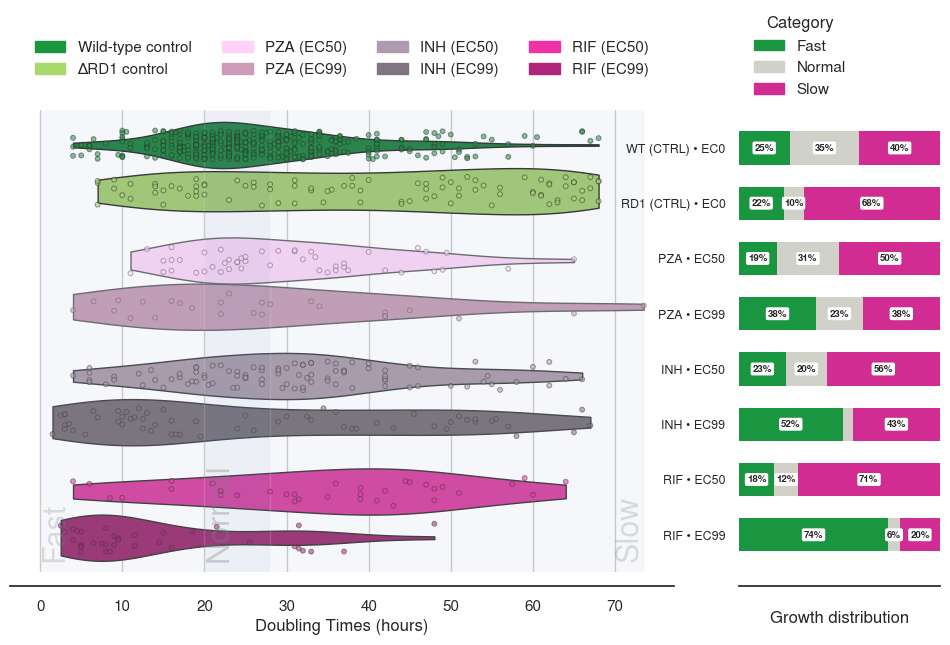

In [22]:
doubling_times_with_stacked_bars(subset_df, expanded_piyg)

# Doubling times with stacked bars box

In [30]:
def doubling_times_with_stacked_bars_box(subset_df, expanded_piyg,
                                         width_in=12, height_in=6, bar_height=0.6):
    """
    Left: box + strip plots of doubling times.
    Right: stacked horizontal bars (Fast/Normal/Slow) for groups that exist only.
    CTRL is coerced to EC0 (no blank EC50/EC99 rows). Rows top→bottom:
    WT (CTRL) → RD1 (CTRL) → PZA → INH → RIF.
    """
    import warnings
    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from matplotlib.colors import to_rgb, to_hex

    warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

    # Theme
    sns.set_theme(style="white")

    plt.rcParams["font.family"] = "Nimbus Sans"

    df = subset_df.copy()

    # Normalise fields
    for c in ("Compound", "Strain"):
        if c in df:
            df[c] = df[c].astype(str)
    df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
    df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

    # Flatten Doubling Times
    if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
        df = df.explode("Doubling Times", ignore_index=True)

    df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
    df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
    df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

    keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
    df = df.drop_duplicates(subset=keys).copy()

    # Derived labels
    bins = [0, 20, 28, np.inf]
    labels = ["Fast", "Normal", "Slow"]
    df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

    df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
    rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
    df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
    df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
    df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                      df["Strain_norm"] + " (CTRL)",
                                      df["Compound"])

    strain_order = ["CTRL", "PZA", "INH", "RIF"]
    right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
    concentration_order = ["EC50", "EC0", "EC99"]
    growth_order = ["Fast", "Normal", "Slow"]

    # --- Colours ---
    fast_c, normal_c, slow_c = '#3A3A3A',  expanded_piyg[3],'#F9F9F9' #expanded_piyg[0], expanded_piyg[3], expanded_piyg[5]  # right-panel bars
    ctrl_wt_c, ctrl_rd1_c = expanded_piyg[0], expanded_piyg[1]

    # helper for light/dark
    def _shade(hex_color, factor=1.0):
        r, g, b = to_rgb(hex_color)
        r = min(1, r * factor); g = min(1, g * factor); b = min(1, b * factor)
        return to_hex((r, g, b))

    compound_base = {
        "PZA": expanded_piyg[4],
        "INH": expanded_piyg[2],
        "RIF": expanded_piyg[5],
    }
    compound_pairs = {k: (_shade(v, 1.15), _shade(v, 0.85)) for k, v in compound_base.items()}

    def conc_palette_for(compound, present_concs):
        light, dark = compound_pairs[compound]
        def pick(c):
            if c in ("EC0", "EC50"):
                return light
            elif c == "EC99":
                return dark
            return light
        return [pick(c) for c in present_concs]

    # --- Figure layout ---
    fig = plt.figure(figsize=(width_in, height_in))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
    ax = plt.subplot(gs[0])
    ax_bar = plt.subplot(gs[1])

    # ---------- LEFT PANEL: BOX + STRIP ----------
    # Controls
    ctrl_df = df[df["Mtb Strain or Drug Compound"] == "CTRL"]
    if not ctrl_df.empty:
        sns.boxplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            palette=[ctrl_wt_c, ctrl_rd1_c],
            whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax
        )
        if ax.legend_: ax.legend_.remove()
        sns.stripplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            palette=[ctrl_wt_c, ctrl_rd1_c],
            jitter=0.25, size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

    # Drugs
    drug_df = df[df["Mtb Strain or Drug Compound"] != "CTRL"]
    for compound in ["PZA", "INH", "RIF"]:
        sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
        if sub.empty:
            continue
        present = [c for c in concentration_order if c in sub["Concentration"].unique()]
        pal = conc_palette_for(compound, present)

        sns.boxplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True, palette=pal,
            whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax
        )
        if ax.legend_: ax.legend_.remove()
        sns.stripplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True, palette=pal,
            jitter=0.25, size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

    # Bands + labels
    xmax = float(df["Doubling Times"].max())
    ax.axvspan(0, 20, alpha=0.05)
    ax.axvspan(20, 28, alpha=0.10)
    ax.axvspan(28, xmax, alpha=0.05)
    ymax = len(strain_order) - 0.65
    ax.text(0, ymax, "Fast", fontsize=22, color="gray", alpha=0.25, ha="left", rotation=90)
    ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left", rotation=90)
    ax.text(xmax, ymax, "Slow", fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

    ax.set_xlabel("Doubling Times (hours)")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.xaxis.grid(True)
    sns.despine(offset=10, left=True, ax=ax)

    # Legend (controls + per-compound pairs)
    legend_handles = [
        mpatches.Patch(color=ctrl_wt_c, label="Wild-type control"),
        mpatches.Patch(color=ctrl_rd1_c, label="ΔRD1 control"),
        mpatches.Patch(color=compound_pairs["PZA"][0], label="PZA (EC50)"),
        mpatches.Patch(color=compound_pairs["PZA"][1], label="PZA (EC99)"),
        mpatches.Patch(color=compound_pairs["INH"][0], label="INH (EC50)"),
        mpatches.Patch(color=compound_pairs["INH"][1], label="INH (EC99)"),
        mpatches.Patch(color=compound_pairs["RIF"][0], label="RIF (EC50)"),
        mpatches.Patch(color=compound_pairs["RIF"][1], label="RIF (EC99)"),
    ]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, 1.18), ncol=4, frameon=False)

    # ---------- RIGHT PANEL: STACKED BARS ----------
    g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
           .size()
           .unstack("Growth Category", fill_value=0))

    rows = [(comp, conc)
            for comp in right_row_order
            for conc in ["EC50", "EC0", "EC99"]
            if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

    if rows:
        g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
        totals = g.sum(axis=1).replace(0, np.nan)
        props = (g.T / totals).T.fillna(0.0)

        y_pos = np.arange(len(props))
        y_labels = [f"{comp} • {conc}" for comp, conc in props.index]
        growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

        lefts = np.zeros(len(props))
        for gr in ["Fast", "Normal", "Slow"]:
            vals = props[gr].values
            bars = ax_bar.barh(
                y=y_pos, width=vals, left=lefts, height=bar_height,
                label=gr, color=growth_colors[gr], edgecolor="none"
            )
            for bar, v in zip(bars, vals):
                if v > 0.05:
                    x_center = bar.get_x() + bar.get_width() / 2
                    y_center = bar.get_y() + bar.get_height() / 2
                    ax_bar.text(
                        x_center, y_center, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=7, fontweight="bold",
                        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                    )
            lefts += vals

        ax_bar.set_xlim(0, 1)
        ax_bar.set_xticks([])
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(y_labels, fontsize=9)
        ax_bar.set_xlabel("\nGrowth distribution")
        ax_bar.set_ylabel("")
        ax_bar.invert_yaxis()
        sns.despine(offset=10, left=True, ax=ax_bar)

        handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
        ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
    else:
        ax_bar.axis("off")

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2158413/2229508116.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


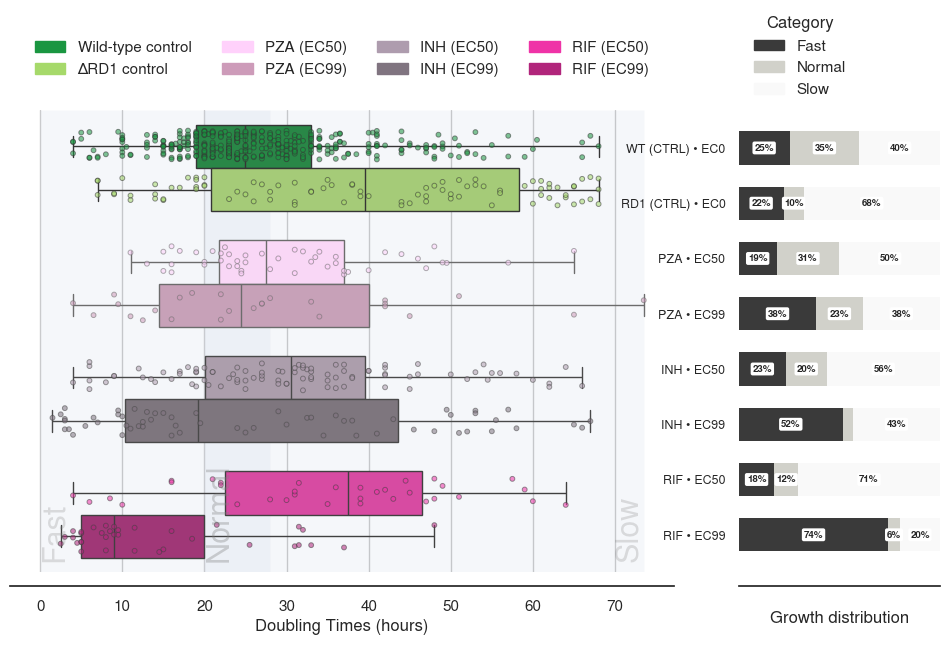

In [31]:
doubling_times_with_stacked_bars_box(subset_df, expanded_piyg)

In [17]:
def doubling_times_with_stacked_bars_box(subset_df, expanded_piyg,
                                         width_in=12, height_in=6, bar_height=0.6):
    """
    Left: box + strip plots of doubling times.
    Right: stacked horizontal bars (Fast/Normal/Slow) for groups that exist only.
    CTRL is coerced to EC0 (no blank EC50/EC99 rows). Rows top→bottom:
    WT (CTRL) → RD1 (CTRL) → PZA → INH → RIF.
    
    MODIFIED: Boxplots are blank (white fill, black edge).
    Stripplot points are colored by Growth Category (Fast, Normal, Slow).
    """
    import warnings
    import matplotlib.gridspec as gridspec
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from matplotlib.colors import to_rgb, to_hex

    warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

    # Theme
    sns.set_theme(style="white")

    plt.rcParams["font.family"] = "Nimbus Sans"

    df = subset_df.copy()

    # Normalise fields
    for c in ("Compound", "Strain"):
        if c in df:
            df[c] = df[c].astype(str)
    df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
    df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

    # Flatten Doubling Times
    if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
        df = df.explode("Doubling Times", ignore_index=True)

    df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
    df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
    df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

    keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
    df = df.drop_duplicates(subset=keys).copy()

    # Derived labels
    bins = [0, 20, 28, np.inf]
    labels = ["Fast", "Normal", "Slow"]
    df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

    df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
    rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
    df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
    df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
    df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                        df["Strain_norm"] + " (CTRL)",
                                        df["Compound"])

    strain_order = ["CTRL", "PZA", "INH", "RIF"]
    right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
    concentration_order = ["EC50", "EC0", "EC99"]
    growth_order = ["Fast", "Normal", "Slow"]

    # --- Colours ---
    # Colors for right-panel bars AND left-panel stripplot
    fast_c, normal_c, slow_c = '#A6D96A',  '#F1C2F2','#D02C91'
    growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}
    
    # Properties for "blank" boxplots with black outlines
    box_plot_props = {
        'boxprops': {'facecolor': '#FFFFFF', 'edgecolor': 'black'},
        'medianprops': {'color': 'black'},
        'whiskerprops': {'color': 'black'},
        'capprops': {'color': 'black'}
    }

    # --- Figure layout ---
    fig = plt.figure(figsize=(width_in, height_in))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
    ax = plt.subplot(gs[0])
    ax_bar = plt.subplot(gs[1])

    # ---------- LEFT PANEL: BOX + STRIP ----------
    # Controls
    ctrl_df = df[df["Mtb Strain or Drug Compound"] == "CTRL"]
    if not ctrl_df.empty:
        sns.boxplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type", order=strain_order, dodge=True,
            whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
            **box_plot_props
        )
        if ax.legend_: ax.legend_.remove()
        sns.stripplot(
            data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Growth Category", hue_order=growth_order, palette=growth_colors,
            order=strain_order, dodge=True,
            jitter=0.25, size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

    # Drugs
    drug_df = df[df["Mtb Strain or Drug Compound"] != "CTRL"]
    for compound in ["PZA", "INH", "RIF"]:
        sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
        if sub.empty:
            continue
        present = [c for c in concentration_order if c in sub["Concentration"].unique()]

        sns.boxplot(
            data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration", order=strain_order, hue_order=present,
            dodge=True,
            whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
            **box_plot_props
        )
        if ax.legend_: ax.legend_.remove()

        # MODIFICATION: Loop by growth category to set color,
        # but use `hue="Concentration"` for correct dodge positioning.
        for category in growth_order:
            category_df = sub[sub["Growth Category"] == category]
            if category_df.empty:
                continue
            sns.stripplot(
                data=category_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
                hue="Concentration", # <-- Use same hue as boxplot for correct dodging
                order=strain_order, 
                hue_order=present, # <-- Use same hue_order as boxplot
                dodge=True,
                color=growth_colors[category], # <-- Set color manually
                jitter=0.25, size=3.5, linewidth=0.7, edgecolor="auto", alpha=0.55, ax=ax
            )
            if ax.legend_: ax.legend_.remove() # Remove auto-legend

    # Bands + labels
    xmax = float(df["Doubling Times"].max())
    ax.axvspan(0, 20, alpha=0.05)
    ax.axvspan(20, 28, alpha=0.10)
    ax.axvspan(28, xmax, alpha=0.05)
    ymax = len(strain_order) - 0.65
    ax.text(0, ymax, "Fast", fontsize=22, color="gray", alpha=0.25, ha="left", rotation=90)
    ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left", rotation=90)
    ax.text(xmax, ymax, "Slow", fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

    ax.set_xlabel("Doubling Times (hours)")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.xaxis.grid(True)
    sns.despine(offset=10, left=True, ax=ax)

    # Legend (Fast/Normal/Slow)
    legend_handles = [
        mpatches.Patch(color=fast_c, label="Fast"),
        mpatches.Patch(color=normal_c, label="Normal"),
        mpatches.Patch(color=slow_c, label="Slow", edgecolor='black'), # Add edge to white patch
    ]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

    # ---------- RIGHT PANEL: STACKED BARS ----------
    g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
           .size()
           .unstack("Growth Category", fill_value=0))

    rows = [(comp, conc)
            for comp in right_row_order
            for conc in ["EC50", "EC0", "EC99"]
            if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

    if rows:
        g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
        totals = g.sum(axis=1).replace(0, np.nan)
        props = (g.T / totals).T.fillna(0.0)

        y_pos = np.arange(len(props))
        y_labels = [f"{comp} • {conc}" for comp, conc in props.index]
        # This (growth_colors) already matches the stripplot
        # growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

        lefts = np.zeros(len(props))
        for gr in ["Fast", "Normal", "Slow"]:
            if gr not in props.columns: continue # Safety check
            vals = props[gr].values
            bars = ax_bar.barh(
                y=y_pos, width=vals, left=lefts, height=bar_height,
                label=gr, color=growth_colors[gr], edgecolor="none"
            )
            for bar, v in zip(bars, vals):
                if v > 0.05:
                    x_center = bar.get_x() + bar.get_width() / 2
                    y_center = bar.get_y() + bar.get_height() / 2
                    ax_bar.text(
                        x_center, y_center, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=7, fontweight="bold",
                        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                    )
            lefts += vals

        ax_bar.set_xlim(0, 1)
        ax_bar.set_xticks([])
        ax_bar.set_yticks(y_pos)
        ax_bar.set_yticklabels(y_labels, fontsize=9)
        ax_bar.set_xlabel("\nGrowth distribution")
        ax_bar.set_ylabel("")
        ax_bar.invert_yaxis()
        sns.despine(offset=10, left=True, ax=ax_bar)

        handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
        ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
    else:
        ax_bar.axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_194649/3369718086.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


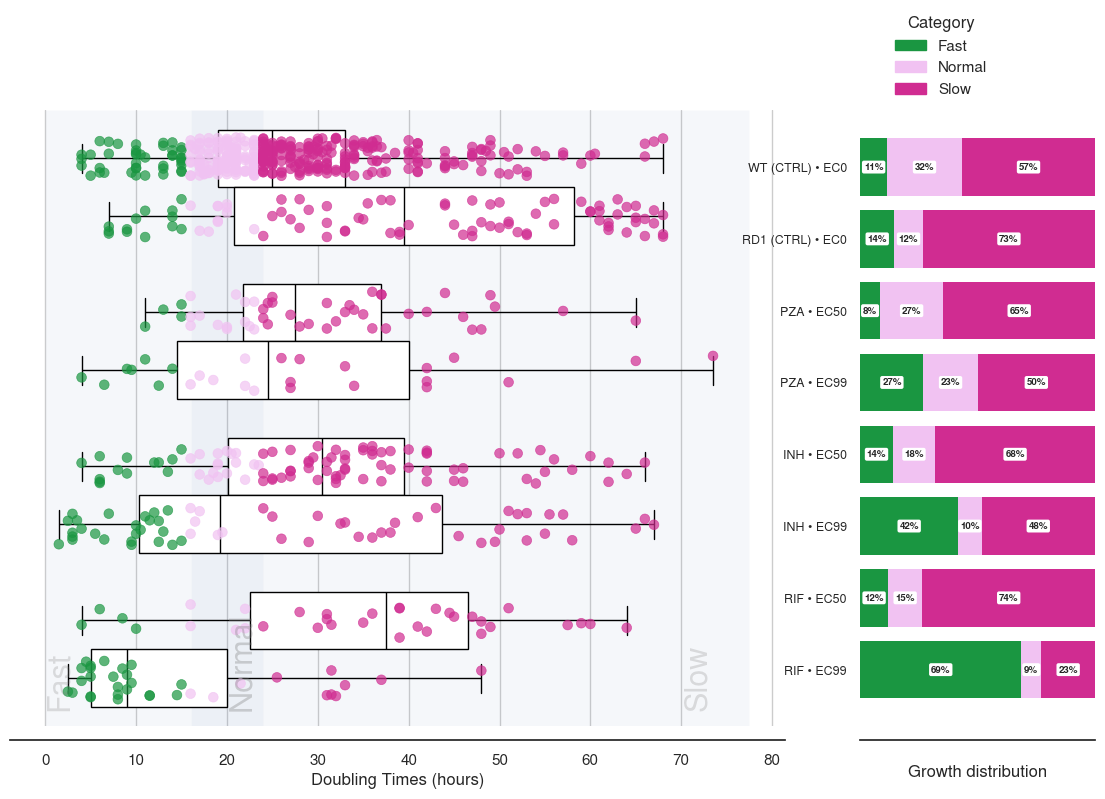

In [72]:
# def doubling_times_with_stacked_bars_box(subset_df, expanded_piyg,
#                                          width_in=12, height_in=6, bar_height=0.6):
#     """
#     Left: box + strip plots of doubling times.
#     Right: stacked horizontal bars (Fast/Normal/Slow) for groups that exist only.
#     CTRL is coerced to EC0 (no blank EC50/EC99 rows). Rows top→bottom:
#     WT (CTRL) → RD1 (CTRL) → PZA → INH → RIF.
    
#     MODIFIED: Boxplots are blank (white fill, black edge).
#     Stripplot points are colored by Growth Category (Fast, Normal, Slow).
#     """
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_rgb, to_hex

warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# Theme
sns.set_theme(style="white")

plt.rcParams["font.family"] = "Nimbus Sans"

df = subset_df.copy()

# Normalise fields
for c in ("Compound", "Strain"):
    if c in df:
        df[c] = df[c].astype(str)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

# Flatten Doubling Times
if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
    df = df.explode("Doubling Times", ignore_index=True)

df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# Derived labels
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                    df["Strain_norm"] + " (CTRL)",
                                    df["Compound"])

strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
concentration_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# --- Colours ---
# Colors for right-panel bars AND left-panel stripplot
fast_c, normal_c, slow_c = expanded_piyg[0],  '#F1C2F2','#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

# Properties for "blank" boxplots with black outlines
box_plot_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# --- Figure layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# ---------- REPLACE CTRL stripplot section with this ----------
if not ctrl_df.empty:
    sns.boxplot(
        data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="CTRL Type", order=strain_order, dodge=True,
        whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
        **box_plot_props
    )
    if ax.legend_: ax.legend_.remove()
    
    # for each growth category, map every hue-level to the same growth color so dodge is preserved
    hue_levels = list(ctrl_df["CTRL Type"].dropna().unique())
    for category in growth_order:
        category_df = ctrl_df[ctrl_df["Growth Category"] == category]
        if category_df.empty:
            continue
        # build a palette mapping: every hue level -> growth color
        palette_map = {lvl: growth_colors[category] for lvl in hue_levels}
        sns.stripplot(
            data=category_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type",
            order=strain_order,
            dodge=True,
            palette=palette_map,
            jitter=0.25, size=7,
            linewidth=0.5, edgecolor=growth_colors[category], alpha=0.7, ax=ax
        )
        if ax.legend_: ax.legend_.remove()


# ---------- REPLACE Drug stripplot section with this ----------
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if sub.empty:
        continue
    present = [c for c in concentration_order if c in sub["Concentration"].unique()]

    sns.boxplot(
        data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="Concentration",
        order=strain_order, hue_order=present,
        dodge=True,
        whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
        **box_plot_props
    )
    if ax.legend_: ax.legend_.remove()

    # precompute existing hue levels (concentration strings present)
    hue_levels = [lvl for lvl in present]

    for category in growth_order:
        category_df = sub[sub["Growth Category"] == category]
        if category_df.empty:
            continue
        # map all concentration levels to the growth color for this category
        palette_map = {lvl: growth_colors[category] for lvl in hue_levels}
        sns.stripplot(
            data=category_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration",
            order=strain_order,
            hue_order=present,
            dodge=True,
            palette=palette_map,
            jitter=0.25, size=7,
            linewidth=0.5, edgecolor=growth_colors[category], alpha=0.7, ax=ax
        )
        if ax.legend_: ax.legend_.remove()


# Bands + labels
xmax = float(df["Doubling Times"].max())
if pd.isna(xmax): xmax = 60 # Fallback
ax.axvspan(bins[0], bins[1], alpha=0.05)
ax.axvspan(bins[1], bins[2], alpha=0.10)
ax.axvspan(bins[2], xmax+4, alpha=0.05)
ymax = len(strain_order) - 0.65
ax.text(0, ymax, "Fast", fontsize=22, color="gray", alpha=0.25, ha="left", rotation=90)
ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left", rotation=90)
ax.text(xmax, ymax, "Slow", fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

ax.set_xlabel("Doubling Times (hours)")
ax.set_ylabel("")
ax.set_yticks([])
ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# # Legend (Fast/Normal/Slow)
# legend_handles = [
#     mpatches.Patch(color=fast_c, label="Fast"),
#     mpatches.Patch(color=normal_c, label="Normal"),
#     mpatches.Patch(color=slow_c, label="Slow", edgecolor='black'),
# ]
# ax.legend(handles=legend_handles, loc="upper center",
#           bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

# ---------- RIGHT PANEL: STACKED BARS ----------
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
       .size()
       .unstack("Growth Category", fill_value=0))

rows = [(comp, conc)
        for comp in right_row_order
        for conc in ["EC50", "EC0", "EC99"]
        if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if rows:
    g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
    totals = g.sum(axis=1).replace(0, np.nan)
    props = (g.T / totals).T.fillna(0.0)

    y_pos = np.arange(len(props))
    y_labels = [f"{comp} • {conc}" for comp, conc in props.index]

    lefts = np.zeros(len(props))
    for gr in ["Fast", "Normal", "Slow"]:
        if gr not in props.columns: continue
        vals = props[gr].values
        bars = ax_bar.barh(
            y=y_pos, width=vals, left=lefts, height=bar_height,
            label=gr, color=growth_colors[gr], edgecolor="none"
        )
        for bar, v in zip(bars, vals):
            if v > 0.05:
                x_center = bar.get_x() + bar.get_width() / 2
                y_center = bar.get_y() + bar.get_height() / 2
                ax_bar.text(
                    x_center, y_center, f"{v*100:.0f}%",
                    ha="center", va="center", fontsize=7, fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                )
        lefts += vals

    ax_bar.set_xlim(0, 1)
    ax_bar.set_xticks([])
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(y_labels, fontsize=9)
    ax_bar.set_xlabel("\nGrowth distribution")
    ax_bar.set_ylabel("")
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
    ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
else:
    ax_bar.axis("off")

plt.tight_layout()
plt.show()
# doubling_times_with_stacked_bars_box(subset_df, expanded_piyg)

/tmp/ipykernel_194649/3513164527.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


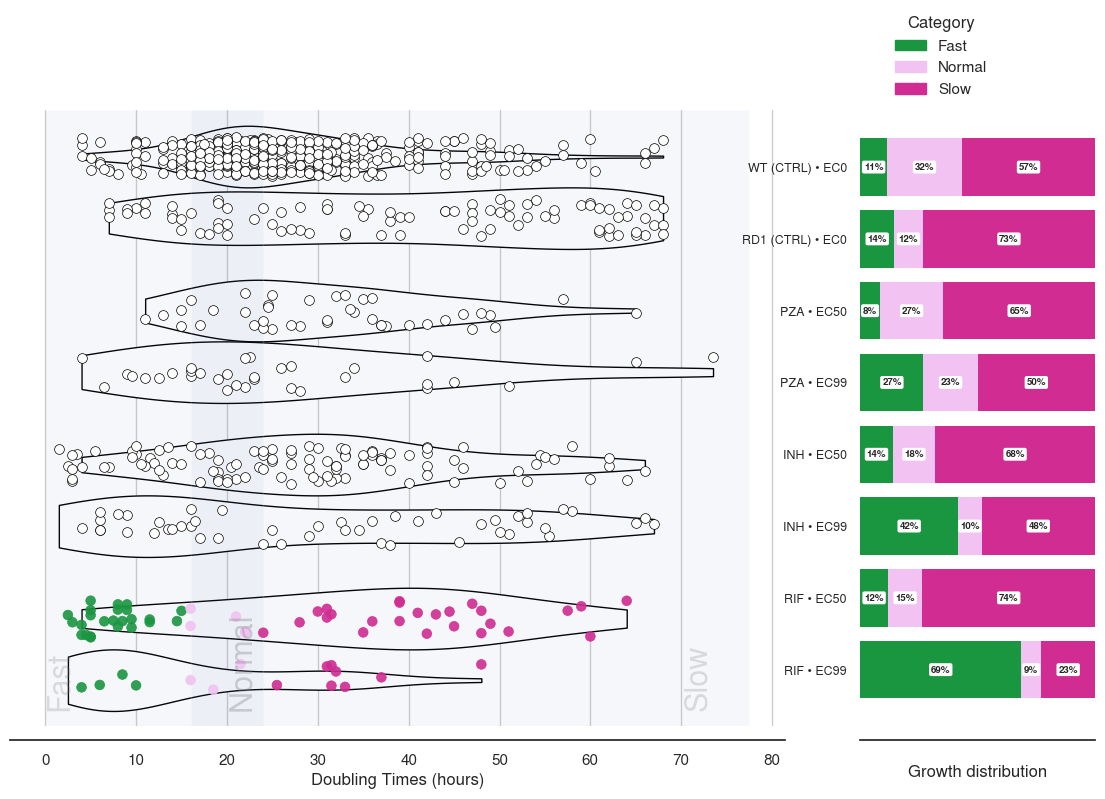

In [74]:
# def doubling_times_with_stacked_bars_box(subset_df, expanded_piyg,
#                                          width_in=12, height_in=6, bar_height=0.6):
#     """
#     Left: box + strip plots of doubling times.
#     Right: stacked horizontal bars (Fast/Normal/Slow) for groups that exist only.
#     CTRL is coerced to EC0 (no blank EC50/EC99 rows). Rows top→bottom:
#     WT (CTRL) → RD1 (CTRL) → PZA → INH → RIF.
    
#     MODIFIED: Boxplots are blank (white fill, black edge).
#     Stripplot points are colored by Growth Category (Fast, Normal, Slow).
#     """
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_rgb, to_hex

warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# Theme
sns.set_theme(style="white")

plt.rcParams["font.family"] = "Nimbus Sans"

df = subset_df.copy()

# Normalise fields
for c in ("Compound", "Strain"):
    if c in df:
        df[c] = df[c].astype(str)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

# Flatten Doubling Times
if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
    df = df.explode("Doubling Times", ignore_index=True)

df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# Derived labels
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(df["Compound"].eq("CTRL"),
                                    df["Strain_norm"] + " (CTRL)",
                                    df["Compound"])

strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
concentration_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# --- Colours ---
# Colors for right-panel bars AND left-panel stripplot
fast_c, normal_c, slow_c = expanded_piyg[0],  '#F1C2F2','#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

# Properties for "blank" boxplots with black outlines
box_plot_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# --- Figure layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.15)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# ---------- REPLACE CTRL violin + stripplot section with this ----------
if not ctrl_df.empty:
    # draw violin plots (blank interior, black outline)
    v = sns.violinplot(
        data=ctrl_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="CTRL Type", order=strain_order, dodge=True,
        cut=0, inner=None, linewidth=1.0, ax=ax
    )
    # style each violin: white fill, black edge
    for violin in v.collections:
        try:
            violin.set_facecolor("white")
            violin.set_edgecolor("black")
            violin.set_alpha(1.0)
        except Exception:
            pass
    if ax.legend_: ax.legend_.remove()

    # compute hue levels for palette mapping
    hue_levels = list(ctrl_df["CTRL Type"].dropna().unique())
    for category in growth_order:
        category_df = ctrl_df[ctrl_df["Growth Category"] == category]
        if category_df.empty:
            continue
        # map every hue level to the growth color so dodge is preserved but color matches growth category
        palette_map = {lvl: growth_colors[category] for lvl in hue_levels}
        sns.stripplot(
            data=category_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="CTRL Type",
            order=strain_order,
            dodge=True,
            palette=palette_map,
            jitter=0.25, size=7,
            linewidth=0.5, edgecolor=growth_colors[category], alpha=0.9, ax=ax
        )
        if ax.legend_: ax.legend_.remove()


# ---------- REPLACE Drug violin + stripplot section with this ----------
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if sub.empty:
        continue
    present = [c for c in concentration_order if c in sub["Concentration"].unique()]

    # violin plots for drugs (outline black, interior white)
    v = sns.violinplot(
        data=sub, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue="Concentration",
        order=strain_order, hue_order=present,
        dodge=True, cut=0, inner=None, linewidth=1.0, ax=ax
    )
    for violin in v.collections:
        try:
            violin.set_facecolor("white")
            violin.set_edgecolor("black")
            violin.set_alpha(1.0)
        except Exception:
            pass
    if ax.legend_: ax.legend_.remove()

    hue_levels = [lvl for lvl in present]
    for category in growth_order:
        category_df = sub[sub["Growth Category"] == category]
        if category_df.empty:
            continue
        palette_map = {lvl: growth_colors[category] for lvl in hue_levels}
        sns.stripplot(
            data=category_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue="Concentration",
            order=strain_order,
            hue_order=present,
            dodge=True,
            palette=palette_map,
            jitter=0.25, size=7,
            linewidth=0.5, edgecolor=growth_colors[category], alpha=0.9, ax=ax
        )
        if ax.legend_: ax.legend_.remove()


# Bands + labels
xmax = float(df["Doubling Times"].max())
if pd.isna(xmax): xmax = 60 # Fallback
ax.axvspan(bins[0], bins[1], alpha=0.05)
ax.axvspan(bins[1], bins[2], alpha=0.10)
ax.axvspan(bins[2], xmax+4, alpha=0.05)
ymax = len(strain_order) - 0.65
ax.text(0, ymax, "Fast", fontsize=22, color="gray", alpha=0.25, ha="left", rotation=90)
ax.text(20, ymax, "Normal", fontsize=22, color="gray", alpha=0.35, ha="left", rotation=90)
ax.text(xmax, ymax, "Slow", fontsize=22, color="gray", alpha=0.25, ha="right", rotation=90)

ax.set_xlabel("Doubling Times (hours)")
ax.set_ylabel("")
ax.set_yticks([])
ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# # Legend (Fast/Normal/Slow)
# legend_handles = [
#     mpatches.Patch(color=fast_c, label="Fast"),
#     mpatches.Patch(color=normal_c, label="Normal"),
#     mpatches.Patch(color=slow_c, label="Slow", edgecolor='black'),
# ]
# ax.legend(handles=legend_handles, loc="upper center",
#           bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

# ---------- RIGHT PANEL: STACKED BARS ----------
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
       .size()
       .unstack("Growth Category", fill_value=0))

rows = [(comp, conc)
        for comp in right_row_order
        for conc in ["EC50", "EC0", "EC99"]
        if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if rows:
    g = g.loc[pd.MultiIndex.from_tuples(rows, names=["Display Compound", "Concentration"])]
    totals = g.sum(axis=1).replace(0, np.nan)
    props = (g.T / totals).T.fillna(0.0)

    y_pos = np.arange(len(props))
    y_labels = [f"{comp} • {conc}" for comp, conc in props.index]

    lefts = np.zeros(len(props))
    for gr in ["Fast", "Normal", "Slow"]:
        if gr not in props.columns: continue
        vals = props[gr].values
        bars = ax_bar.barh(
            y=y_pos, width=vals, left=lefts, height=bar_height,
            label=gr, color=growth_colors[gr], edgecolor="none"
        )
        for bar, v in zip(bars, vals):
            if v > 0.05:
                x_center = bar.get_x() + bar.get_width() / 2
                y_center = bar.get_y() + bar.get_height() / 2
                ax_bar.text(
                    x_center, y_center, f"{v*100:.0f}%",
                    ha="center", va="center", fontsize=7, fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
                )
        lefts += vals

    ax_bar.set_xlim(0, 1)
    ax_bar.set_xticks([])
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(y_labels, fontsize=9)
    ax_bar.set_xlabel("\nGrowth distribution")
    ax_bar.set_ylabel("")
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in ["Fast", "Normal", "Slow"]]
    ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
else:
    ax_bar.axis("off")

plt.tight_layout()
plt.show()
# doubling_times_with_stacked_bars_box(subset_df, expanded_piyg)

/tmp/ipykernel_194649/3956448706.py:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#A6D96A'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_194649/3956448706.py:101: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_194649/3956448706.py:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#F1C2F2'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_194649/3956448706.py:101: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_194649/3956448706.py:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#D02C91'` for the same effect.

  sns.stripplot(
/t

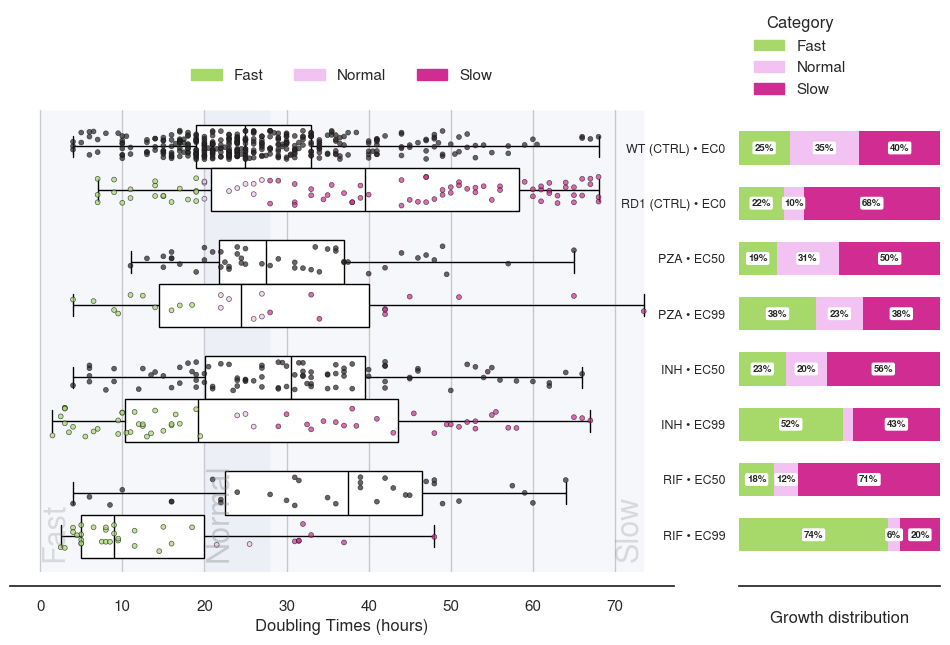

# Stats

In [50]:
def doubling_times_box_with_kw(subset_df, expanded_piyg,
                               width_in=10, height_in=5,
                               show_stats=True):
    """
    Box + strip plots of doubling times by condition,
    with Kruskal–Wallis tests vs. WT (CTRL) baseline.
    """
    import warnings
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    from matplotlib.colors import to_rgb, to_hex
    from scipy.stats import kruskal

    warnings.filterwarnings("ignore")

    sns.set_theme(style="whitegrid")
    plt.rcParams["font.family"] = "Nimbus Sans"

    df = subset_df.copy()

    # --- tidy data ---
    df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
    df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

    if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
        df = df.explode("Doubling Times", ignore_index=True)

    df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
    df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

    rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
    df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
    df["Display"] = np.where(df["Compound"].eq("CTRL"),
                             df["Strain_norm"] + " (CTRL)",
                             df["Compound"] + " " + df["Concentration"])

    # --- colour palette (same logic as before) ---
    ctrl_wt_c, ctrl_rd1_c = expanded_piyg[0], expanded_piyg[1]

    def _shade(hex_color, factor=1.0):
        r, g, b = to_rgb(hex_color)
        return to_hex(tuple(min(1, c * factor) for c in (r, g, b)))

    compound_base = {
        "PZA": expanded_piyg[4],
        "INH": expanded_piyg[2],
        "RIF": expanded_piyg[5],
    }
    compound_pairs = {k: (_shade(v, 1.15), _shade(v, 0.85)) for k, v in compound_base.items()}

    def color_for(row):
        if row["Compound"] == "CTRL":
            return ctrl_wt_c if row["Strain_norm"] == "WT" else ctrl_rd1_c
        base = compound_pairs.get(row["Compound"], ("#AAAAAA", "#777777"))
        return base[0] if row["Concentration"] in ("EC0", "EC50") else base[1]

    df["Color"] = df.apply(color_for, axis=1)

    # --- order ---
    order = ["WT (CTRL)", "RD1 (CTRL)",
             "PZA EC0", "PZA EC50", "PZA EC99",
             "INH EC0", "INH EC50", "INH EC99",
             "RIF EC0", "RIF EC50", "RIF EC99"]
    order = [o for o in order if o in df["Display"].unique()]

    # --- plot ---
    plt.figure(figsize=(width_in, height_in))
    ax = sns.boxplot(
        data=df, x="Doubling Times", y="Display",
        order=order, whis=[0, 100], width=0.6, fliersize=0,
        palette=dict(zip(df["Display"], df["Color"])),
    )
    sns.stripplot(
        data=df, x="Doubling Times", y="Display",
        order=order, palette=dict(zip(df["Display"], df["Color"])),
        size=3, linewidth=0.5, edgecolor="auto", alpha=0.6, ax=ax
    )
    ax.set_xlabel("Doubling time (hours)")
    ax.set_ylabel("")
    sns.despine(offset=10)

    # --- Kruskal–Wallis tests vs WT(CTRL) ---
    wt = df.loc[df["Display"].eq("WT (CTRL)"), "Doubling Times"]
    results = {}
    for cond in order:
        if cond == "WT (CTRL)":
            continue
        vals = df.loc[df["Display"].eq(cond), "Doubling Times"]
        if len(vals) > 3:
            stat, p = kruskal(wt, vals)
            results[cond] = p

    # Annotate
    if show_stats and results:
        # annotate on the plot
        y_positions = {label: i for i, label in enumerate(order)}
        for cond, p in results.items():
            if cond == "WT (CTRL)":
                continue
            y = y_positions[cond]
            label = f"{fmt_p(p)}  {stars(p)}"
            # choose an x where you want the text (e.g. near the 98th percentile)
            x_annot = df.loc[df["Display"] == cond, "Doubling Times"].quantile(0.98)
            ax.text(75, y, label, ha="left", va="center", fontsize=12, color="gray")
        
        
    plt.tight_layout()
    plt.show()

    if results:
        # print clean summary (no raw p)
        print("Kruskal–Wallis vs WT (CTRL):")
        for cond in order:
            if cond == "WT (CTRL)" or cond not in results:
                continue
            p = results[cond]
            print(f"{cond:12s}  {fmt_p(p)}")


In [52]:
def fmt_p(p, zero_floor=1e-300):
    """Format p-values: show all numeric ones, but replace 0 with a floor string."""
    if p == 0 or not np.isfinite(p):
        return f"p < {zero_floor:.0e}"
    return f"p = {p:.3g}"

def stars(p):
    """Return significance stars."""
    if p == 0 or not np.isfinite(p):
        p = 1e-300  # treat zeros as extremely significant
    return (
        "ns" if p >= 0.05 else
        "*" if p >= 0.01 else
        "**" if p >= 0.001 else
        "***"
    )
import numpy as np

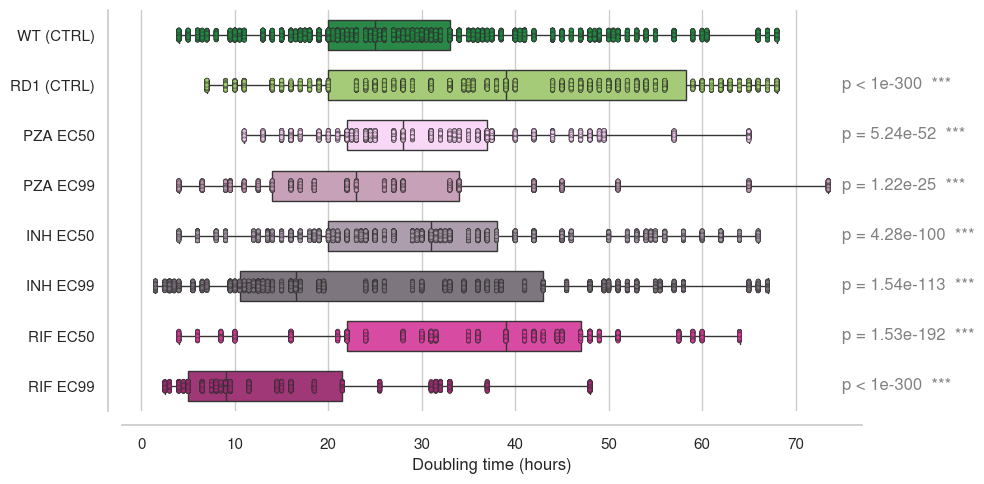

Kruskal–Wallis vs WT (CTRL):
RD1 (CTRL)    p < 1e-300
PZA EC50      p = 5.24e-52
PZA EC99      p = 1.22e-25
INH EC50      p = 4.28e-100
INH EC99      p = 1.54e-113
RIF EC50      p = 1.53e-192
RIF EC99      p < 1e-300


In [53]:
doubling_times_box_with_kw(subset_df, expanded_piyg)

In [55]:
import scikit_posthocs as spy

Omnibus Kruskal–Wallis H = 7318.628, p = 0.000e+00

Dunn’s pairwise comparisons vs WT (CTRL):
INH EC50      <1e-6
INH EC99      <1e-6
PZA EC50      <1e-6
PZA EC99      <1e-6
RD1 (CTRL)    <1e-6
RIF EC50      <1e-6
RIF EC99      <1e-6
Name: WT (CTRL), dtype: object


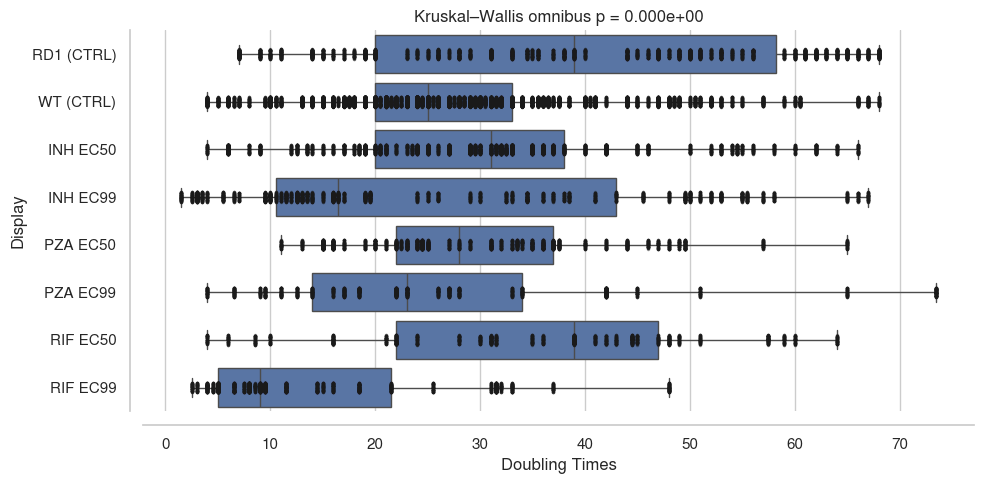

In [56]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# --- prepare data (similar cleanup as before) ---
df = subset_df.copy()
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
    df = df.explode("Doubling Times", ignore_index=True)

df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
df["Display"] = np.where(df["Compound"].eq("CTRL"),
                         df["Strain_norm"] + " (CTRL)",
                         df["Compound"] + " " + df["Concentration"])

# --- 1️⃣ omnibus Kruskal–Wallis across all groups ---
groups = [grp["Doubling Times"].values for _, grp in df.groupby("Display")]
stat, p_omni = kruskal(*groups)
print(f"Omnibus Kruskal–Wallis H = {stat:.3f}, p = {p_omni:.3e}")

# --- 2️⃣ pairwise Dunn’s post-hoc tests ---
# p-values adjusted by Bonferroni or FDR
dunn = sp.posthoc_dunn(df, val_col="Doubling Times", group_col="Display", p_adjust="bonferroni")

# show pairwise p-values vs WT (CTRL)
ref = "WT (CTRL)"
pairwise_vs_ctrl = dunn.loc[ref].drop(ref)
print("\nDunn’s pairwise comparisons vs WT (CTRL):")
print(pairwise_vs_ctrl.apply(lambda p: "<1e-6" if p < 1e-6 else f"{p:.3g}"))

# --- optional: visualise ---
order = sorted(df["Display"].unique(), key=lambda x: ("CTRL" not in x, x))
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Doubling Times", y="Display", order=order, whis=[0, 100], fliersize=0)
sns.stripplot(data=df, x="Doubling Times", y="Display", order=order, color="k", alpha=0.4, size=2.5)
sns.despine(offset=10)
plt.title(f"Kruskal–Wallis omnibus p = {p_omni:.3e}")
plt.tight_layout()
plt.show()


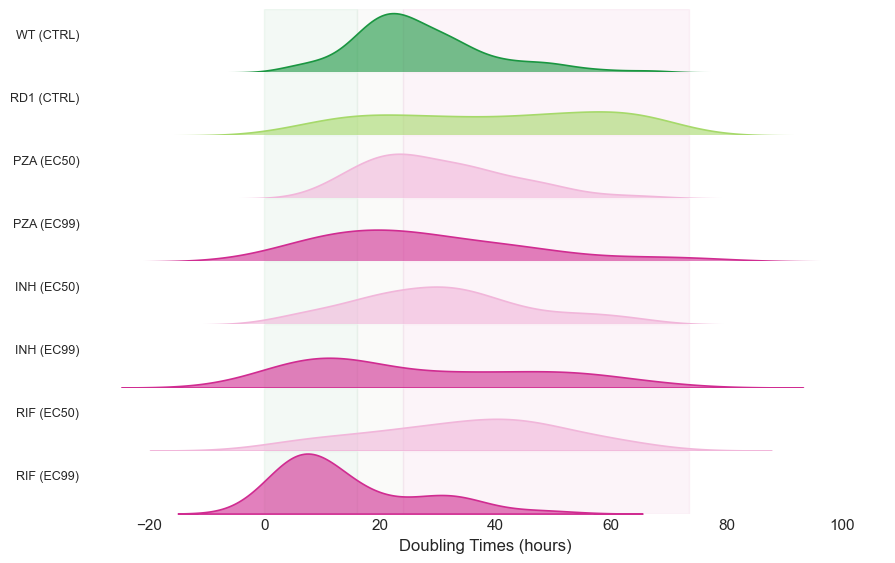

In [13]:
# ... [Data loading and processing from your code remains unchanged] ...
# Assume 'df' is loaded with 'KDE_Hue', 'kde_order_present',
# 'kde_palette_present', 'xmax', and color variables
# (fast_c, normal_c, slow_c)

df = df[df['mtb_origin']=='Growth'].copy()

# Normalize fields
for c in ("Compound", "Strain"):
    if c in df:
        df[c] = df[c].astype(str)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)

# Force CTRL → EC0
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

# Scalarize and clean doubling times
if df["Doubling Times"].apply(lambda v: isinstance(v, (list, tuple, np.ndarray))).any():
    df = df.explode("Doubling Times", ignore_index=True)

df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df["Doubling Times"] = df["Doubling Times"].replace([np.inf, -np.inf], np.nan)
df = df[df["Doubling Times"].notna() & (df["Doubling Times"] > 0)]

# De-dupe repeated points
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# Derived labels
bins = [0, 20, 28, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])
rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")
df["CTRL Type"] = np.where(df["Compound"].eq("CTRL"), df["Strain_norm"], pd.NA)

df["KDE_Hue"] = np.where(
    df["Compound"].eq("CTRL"),
    df["Strain_norm"] + " (CTRL)",
    df["Compound"] + " (" + df["Concentration"] + ")"
)

# Colors
fast_c, normal_c, slow_c = expanded_piyg[0], expanded_piyg[3], expanded_piyg[5]
ctrl_wt_c, ctrl_rd1_c = expanded_piyg[0], expanded_piyg[1]
ec50_c, ec0_c, ec99_c = expanded_piyg[4], expanded_piyg[2], expanded_piyg[5]

# --- MODIFICATION: Define order and palette for the new KDE_Hue ---
kde_order = [
    "WT (CTRL)", "RD1 (CTRL)",
    "PZA (EC0)", "PZA (EC50)", "PZA (EC99)",
    "INH (EC0)", "INH (EC50)", "INH (EC99)",
    "RIF (EC0)", "RIF (EC50)", "RIF (EC99)"
]

# Filter for only those present in the data
present_hues = df["KDE_Hue"].unique()
kde_order_present = [h for h in kde_order if h in present_hues]

# Build the palette dictionary
kde_palette = {
    "WT (CTRL)": ctrl_wt_c,
    "RD1 (CTRL)": ctrl_rd1_c,
    "PZA (EC0)": ec0_c, "PZA (EC50)": ec50_c, "PZA (EC99)": ec99_c,
    "INH (EC0)": ec0_c, "INH (EC50)": ec50_c, "INH (EC99)": ec99_c,
    "RIF (EC0)": ec0_c, "RIF (EC50)": ec50_c, "RIF (EC99)": ec99_c
}
kde_palette_present = {k: v for k, v in kde_palette.items() if k in present_hues}
xmax = float(df["Doubling Times"].max())

# --- MODIFICATION: Build FacetGrid for Ridgeline Plot ---

# Set the background to white
plt.style.use('seaborn-v0_8-white')

# 1. Initialize the FacetGrid. 'row' defines the stacking.
# 'height' is per-facet, 'aspect' controls width-to-height ratio.
g = sns.FacetGrid(
    df,
    row="KDE_Hue",          # Each category gets its own row
    hue="KDE_Hue",          # Color each row by its category
    row_order=kde_order_present, # Control the stacking order
    palette=kde_palette_present,
    height=0.75,            # Height of each individual plot
    aspect=12               # Width = aspect * height
)

# 2. Add the background color bands to each facet
# We define a helper function to pass to g.map
def plot_spans(*args, **kwargs):
    ax = plt.gca()
    ax.axvspan(0, 16, color=fast_c, alpha=0.05, zorder=0)
    ax.axvspan(16, 24, color=normal_c, alpha=0.10, zorder=0)
    ax.axvspan(24, xmax, color=slow_c, alpha=0.05, zorder=0)

g.map(plot_spans)

# 3. Draw the KDEs. 'fill=True' creates the shaded area.
g.map_dataframe(
    sns.kdeplot,
    x="Doubling Times",
    fill=True,
    alpha=0.6,
    # cut=0,
    linewidth=1.2
)

# # 4. (Optional) Add a rugplot to show individual points
# g.map_dataframe(
#     sns.rugplot,
#     x="Doubling Times",
#     height=0.15,
#     alpha=0.4
# )

# 5. --- This is the critical step ---
# Adjust vertical spacing. A negative value overlaps the plots.
# -0.6 means a 60% overlap.
g.figure.subplots_adjust(hspace=-0.)

# 6. --- MODIFICATION: Clean up axes and add left-hand labels ---
# Use row_template="" to hide the default right-hand side labels
g.set_titles(row_template="")

# Set x-label on the bottom-most plot
g.set_axis_labels("Doubling Times (hours)", "")

# Remove y-ticks from all plots
g.set(yticks=[])

# Iterate through the axes (g.axes.flat) and add manual y-labels
for ax, label in zip(g.axes.flat, kde_order_present):
    # Add the label to the left
    # rotation=0 makes it horizontal
    # ha='right' aligns it to the right, next to the plot
    # Adjust fontsize as needed
    ax.set_ylabel(label, rotation=0, ha='right', fontsize=9)

# Remove the left spine and bottom spine
g.despine(left=True, bottom=True, offset=10)

# plt.savefig('rebuttal_figs/ridgeline_kde_plot_wout_cut.pdf', bbox_inches='tight', dpi=314)
plt.show()